# CIFAR-10 Classification with Vision Transformer (ViT-B/16)

Fine-tuning pretrained ViT-B/16 on CIFAR-10.

Based on: *An Image is Worth 16x16 Words* (Dosovitskiy et al.)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import autocast, GradScaler
import torchvision
import torchvision.transforms as transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CIFAR10_LABELS = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## Hyperparameters

In [2]:
IMAGE_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 10
EPOCHS_PHASE1 = 3
EPOCHS_PHASE2 = 15
LR_PHASE1 = 1e-3
LR_PHASE2 = 3e-5
WEIGHT_DECAY = 1e-4

print(f'Phase 1: {EPOCHS_PHASE1} epochs (freeze backbone, lr={LR_PHASE1})')
print(f'Phase 2: {EPOCHS_PHASE2} epochs (fine-tune all, lr={LR_PHASE2})')

Phase 1: 3 epochs (freeze backbone, lr=0.001)
Phase 2: 15 epochs (fine-tune all, lr=3e-05)


## Data Loading

In [3]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.1),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}')

100%|██████████| 170M/170M [00:45<00:00, 3.76MB/s]


Train: 50000, Test: 10000


## Load Pretrained ViT-B/16

In [4]:
def create_vit_model(num_classes):
    model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    # Replace classifier head (ViT uses heads.head)
    num_features = model.heads.head.in_features  # 768
    model.heads.head = nn.Linear(num_features, num_classes)
    return model

model = create_vit_model(NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'ViT-B/16 parameters: {total_params:,}')

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:23<00:00, 15.0MB/s]


ViT-B/16 parameters: 85,806,346


## Training Function

In [5]:
def train_phase(model, train_loader, test_loader, epochs, lr, weight_decay,
                device, phase_name='Phase', freeze_backbone=False):
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler('cuda') if device.type == 'cuda' else None

    # Freeze/unfreeze backbone (everything except heads.head)
    for name, param in model.named_parameters():
        if 'heads.head' not in name:
            param.requires_grad = not freeze_backbone

    # Collect params
    head_params = [p for n, p in model.named_parameters() if 'heads.head' in n]
    backbone_params = [p for n, p in model.named_parameters() if 'heads.head' not in n and p.requires_grad]

    if freeze_backbone:
        optimizer = optim.AdamW(head_params, lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': lr * 0.1},
            {'params': head_params, 'lr': lr}
        ], weight_decay=weight_decay)

    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'lr': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        start = time.time()

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            optimizer.zero_grad()
            if scaler:
                with autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == targets).sum().item()
            train_total += targets.size(0)

        scheduler.step()
        lr_now = optimizer.param_groups[0]['lr']

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                val_correct += (outputs.argmax(1) == targets).sum().item()
                val_total += targets.size(0)

        train_acc = 100. * train_correct / train_total
        val_acc = 100. * val_correct / val_total
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss / len(train_loader))
        history['lr'].append(lr_now)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        elapsed = time.time() - start
        print(f'  [{epoch+1:2d}/{epochs}] {phase_name} — '
              f'Train: {train_acc:.1f}% | Val: {val_acc:.1f}% | '
              f'LR: {lr_now:.2e} | Time: {elapsed:.0f}s')

    if best_state:
        model.load_state_dict(best_state)
    print(f'  Best {phase_name} Val Acc: {best_val_acc:.2f}%\n')
    return history

print('Ready.')

Ready.


## Train ViT-B/16

In [6]:
print('=' * 60)
print('Training ViT-B/16')
print('=' * 60)

print('\nPHASE 1: Train classifier head only')
h1 = train_phase(model, train_loader, test_loader,
                 EPOCHS_PHASE1, LR_PHASE1, WEIGHT_DECAY,
                 device, 'P1', freeze_backbone=True)

print('PHASE 2: Fine-tune entire network')
h2 = train_phase(model, train_loader, test_loader,
                 EPOCHS_PHASE2, LR_PHASE2, WEIGHT_DECAY,
                 device, 'P2', freeze_backbone=False)

history = {k: h1[k] + h2[k] for k in h1}
print('Done!')

Training ViT-B/16

PHASE 1: Train classifier head only
  [ 1/3] P1 — Train: 91.6% | Val: 94.9% | LR: 7.50e-04 | Time: 72s
  [ 2/3] P1 — Train: 93.9% | Val: 95.3% | LR: 2.51e-04 | Time: 69s
  [ 3/3] P1 — Train: 94.7% | Val: 95.3% | LR: 1.00e-06 | Time: 69s
  Best P1 Val Acc: 95.32%

PHASE 2: Fine-tune entire network
  [ 1/15] P2 — Train: 96.4% | Val: 97.3% | LR: 2.98e-06 | Time: 90s
  [ 2/15] P2 — Train: 97.6% | Val: 97.6% | LR: 2.91e-06 | Time: 89s
  [ 3/15] P2 — Train: 98.1% | Val: 97.9% | LR: 2.81e-06 | Time: 90s
  [ 4/15] P2 — Train: 98.7% | Val: 97.8% | LR: 2.67e-06 | Time: 89s
  [ 5/15] P2 — Train: 98.9% | Val: 98.0% | LR: 2.50e-06 | Time: 89s
  [ 6/15] P2 — Train: 99.2% | Val: 98.1% | LR: 2.31e-06 | Time: 89s
  [ 7/15] P2 — Train: 99.3% | Val: 98.2% | LR: 2.10e-06 | Time: 90s
  [ 8/15] P2 — Train: 99.5% | Val: 98.2% | LR: 1.90e-06 | Time: 89s
  [ 9/15] P2 — Train: 99.5% | Val: 98.2% | LR: 1.69e-06 | Time: 89s
  [10/15] P2 — Train: 99.6% | Val: 98.2% | LR: 1.50e-06 | Time: 89s
  [

## Evaluate

In [7]:
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        preds = model(inputs.to(device)).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.numpy())

final_acc = 100. * np.mean(np.array(all_preds) == np.array(all_targets))
print(f'Final Test Accuracy: {final_acc:.2f}%')

Final Test Accuracy: 98.36%


## Confusion Matrix

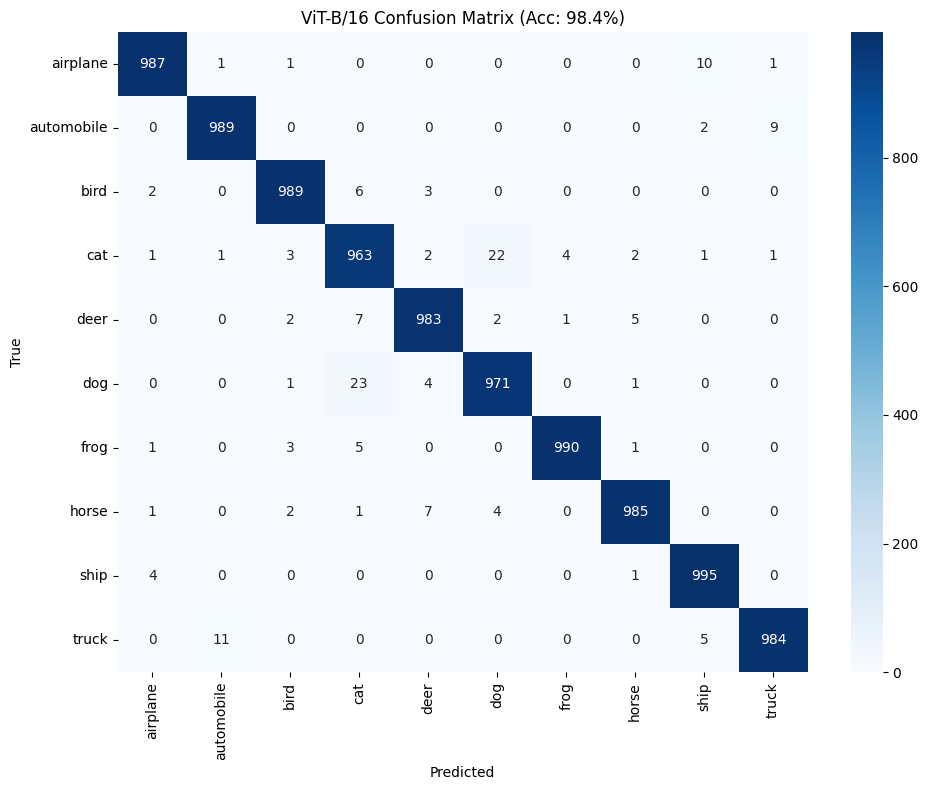

              precision    recall  f1-score   support

    airplane       0.99      0.99      0.99      1000
  automobile       0.99      0.99      0.99      1000
        bird       0.99      0.99      0.99      1000
         cat       0.96      0.96      0.96      1000
        deer       0.98      0.98      0.98      1000
         dog       0.97      0.97      0.97      1000
        frog       0.99      0.99      0.99      1000
       horse       0.99      0.98      0.99      1000
        ship       0.98      0.99      0.99      1000
       truck       0.99      0.98      0.99      1000

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [8]:
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_LABELS, yticklabels=CIFAR10_LABELS)
plt.title(f'ViT-B/16 Confusion Matrix (Acc: {final_acc:.1f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

print(classification_report(all_targets, all_preds, target_names=CIFAR10_LABELS))

## Training Curves

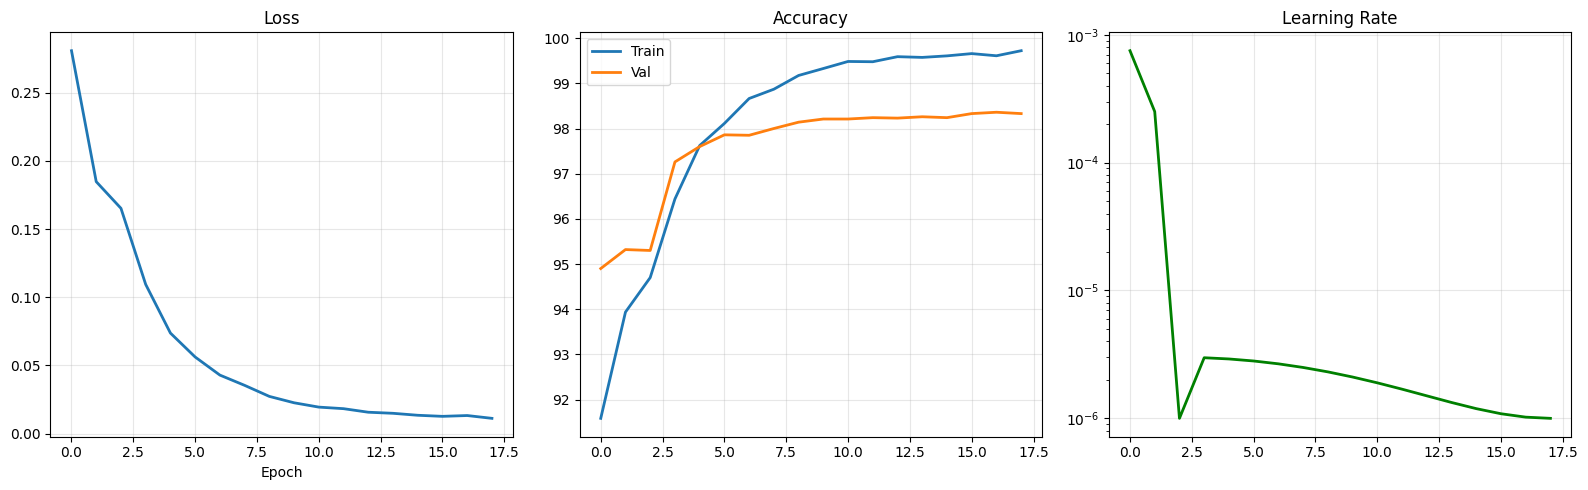

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(history['train_loss'], linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'], label='Val', linewidth=2)
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], linewidth=2, color='green')
axes[2].set_title('Learning Rate')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Calibration (ECE + Reliability Diagram)

This section measures **calibration quality**: whether the model's predicted confidence matches its actual correctness.

- `ECE (Expected Calibration Error)`: lower is better
- `Reliability Diagram`: compares average confidence vs. empirical accuracy in each confidence bin
- For **ViT-B/16**, running this on the **full CIFAR-10 test set** is much faster on **Colab GPU** than on local CPU


Device for calibration: cuda
Calibration samples: full test set
ECE: 0.006917
Total evaluated samples: 10000


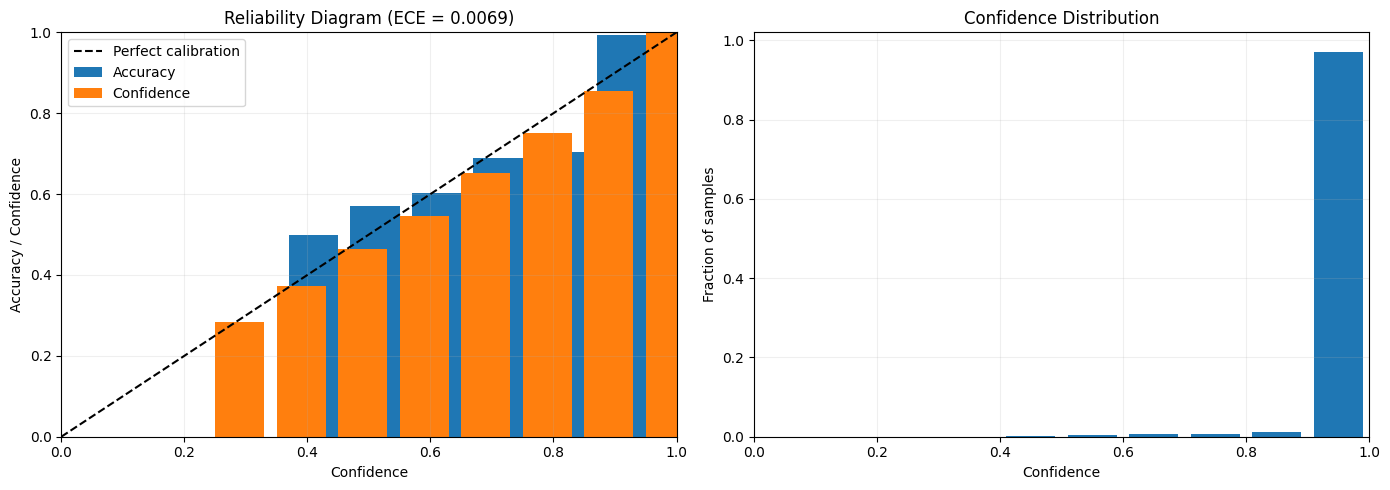

Saved figure to: ../artifacts/vit/vit_b16_calibration_full.png
Saved metrics to: ../artifacts/vit/vit_b16_calibration_metrics_full.json


In [10]:
# Calibration on the test set
# Set to None to use the full 10,000-image CIFAR-10 test split.
# If you only want a quick preview, try 500 or 1000.
from pathlib import Path
import json

CALIBRATION_MAX_SAMPLES = None
N_BINS = 10
MODEL_TAG = 'vit_b16'
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def compute_calibration_metrics(model, data_loader, device, n_bins=10, max_samples=None):
    model.eval()
    all_probs, all_preds, all_targets = [], [], []
    processed = 0

    with torch.inference_mode():
        for inputs, targets in data_loader:
            inputs = inputs.to(device, non_blocking=True)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            targets_np = targets.numpy()

            all_probs.append(probs)
            all_preds.append(preds)
            all_targets.append(targets_np)
            processed += len(targets_np)

            if max_samples is not None and processed >= max_samples:
                break

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    if max_samples is not None:
        all_probs = all_probs[:max_samples]
        all_preds = all_preds[:max_samples]
        all_targets = all_targets[:max_samples]

    confidences = np.max(all_probs, axis=1)
    correctness = (all_preds == all_targets).astype(np.float32)
    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)

    bin_accuracies = []
    bin_confidences = []
    bin_counts = []

    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        if i == 0:
            mask = (confidences >= lower) & (confidences <= upper)
        else:
            mask = (confidences > lower) & (confidences <= upper)

        count = int(mask.sum())
        bin_counts.append(count)

        if count > 0:
            bin_accuracies.append(float(correctness[mask].mean()))
            bin_confidences.append(float(confidences[mask].mean()))
        else:
            bin_accuracies.append(0.0)
            bin_confidences.append(0.0)

    total = len(confidences)
    ece = sum(
        (count / total) * abs(acc - conf)
        for count, acc, conf in zip(bin_counts, bin_accuracies, bin_confidences)
    )

    return ece, bin_accuracies, bin_confidences, bin_counts


def plot_reliability_diagram(ece, bin_accuracies, bin_confidences, bin_counts, save_path=None):
    bin_centers = np.linspace(0.05, 0.95, len(bin_accuracies))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(bin_centers - 0.04, bin_accuracies, width=0.08, label='Accuracy')
    axes[0].bar(bin_centers + 0.04, bin_confidences, width=0.08, label='Confidence')
    axes[0].plot([0, 1], [0, 1], '--', color='black', linewidth=1.5, label='Perfect calibration')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Accuracy / Confidence')
    axes[0].set_title(f'Reliability Diagram (ECE = {ece:.4f})')
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    axes[1].bar(bin_centers, np.array(bin_counts) / max(sum(bin_counts), 1), width=0.08)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Fraction of samples')
    axes[1].set_title('Confidence Distribution')
    axes[1].grid(alpha=0.2)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')

    plt.show()
    return fig


sample_tag = 'full' if CALIBRATION_MAX_SAMPLES is None else f'subset{CALIBRATION_MAX_SAMPLES}'
figure_path = ARTIFACT_DIR / f'{MODEL_TAG}_calibration_{sample_tag}.png'
metrics_path = ARTIFACT_DIR / f'{MODEL_TAG}_calibration_metrics_{sample_tag}.json'

print('Device for calibration:', device)
print('Calibration samples:', 'full test set' if CALIBRATION_MAX_SAMPLES is None else CALIBRATION_MAX_SAMPLES)

ece, bin_accuracies, bin_confidences, bin_counts = compute_calibration_metrics(
    model,
    test_loader,
    device,
    n_bins=N_BINS,
    max_samples=CALIBRATION_MAX_SAMPLES,
)

metrics = {
    'model_tag': MODEL_TAG,
    'sample_tag': sample_tag,
    'ece': float(ece),
    'num_bins': int(N_BINS),
    'total_evaluated_samples': int(sum(bin_counts)),
    'bin_accuracies': [float(x) for x in bin_accuracies],
    'bin_confidences': [float(x) for x in bin_confidences],
    'bin_counts': [int(x) for x in bin_counts],
}

with metrics_path.open('w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print(f'ECE: {ece:.6f}')
print(f'Total evaluated samples: {sum(bin_counts)}')
plot_reliability_diagram(ece, bin_accuracies, bin_confidences, bin_counts, save_path=figure_path)

print(f'Saved figure to: {figure_path}')
print(f'Saved metrics to: {metrics_path}')


In [11]:
torch.save({'model_state_dict': model.state_dict(), 'history': history}, '../models/vit_b16_cifar10.pth')
print('Model saved.')

Model saved.
